In [30]:
# %pip install gensim>=4.1.2

In [31]:
import pandas as pd
from pathlib import Path
import re
import numpy as np
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from nltk.stem import WordNetLemmatizer
from gensim.corpora import Dictionary, MmCorpus
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [32]:
csv_file = Path("../data/customer_support_tickets_eda.csv")
df = pd.read_csv(csv_file)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Description charlength,Ticket Description wordlength
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,290,43
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,288,44
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,277,42
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,264,41
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n\r\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,336,55


In [33]:
df.shape

(8077, 19)

#### **Preprocessing steps**

In [ ]:
# creating a stopwords set

custom_stopwords = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request', 'work', 'working', 'fine',
    'available', 'recent', 'recently','facing', 'doe', 'noticed', 'happening',
    'started', 'happen','different', 'steps', 'did', 'regards','already', 'multiple',
    'last','times','followed', 'reviewed','specific', 'possible', 'related','new',
    'old','find', 'try', 'say', 'mean','name', 'email', 'price', 'one', 'unresolved',
    'add','note', 'may', 'dont', 'know','sure', 'changes', 'performed', 'properly',
    'original','like', 'similar','reported','doesnt', 'sometimes', 'acts', 'works',
    'ensure', 'desired', 'action', 'remains', 'life', 'seems', 'might', 'guide',
    'much', 'others', 'heavily', 'daily', 'task', 'affecting', 'assistance','hoping',
    'persists','didnt','option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making', 'user', 'customer', 'item', 'device','far', 'luck',
    'contact', 'contacted', 'occurring','resolve', 'function', 'came', 'having', 'change',
    'haven', 'let', 'unable', 'able', 'afterward', 'var', 'step', 'order', 've', 'll', 'disqus', 'comments', 'javascript'
}
# {'please', 'assist', 'issue', 'persists', 'product', 'using', 'help', 'resolve', 'function', 'var', 'let', 'having', 'problem', 'thank', 'need', 'soon', 'possible', 'hoping', 'assistance', 'desired', 'customer', 'support', 'step', 'guide', 'action', 'option', 'different', 'available', 'tried', 'facing', 'noticed', 'unable', 'started', 'happening', 'afterward', 'related', 'checked', 'perform', 'performed', 'occurring', 'affecting', 'haven', 'change', 'work', 'fine', 'time', 'recent', 'recently',  'specific', 'thanks', 'like', 'sure', 'say', 'mean', 'user', 'came', 'remains', 'mentioned', 'item', 'order', 'ensure', 'followed', 'reviewed', 'working', 'properly', 'contacted', 'contact', 'unresolved', 'able', 've'}
# {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
#     'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
#     'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
#     'use', 'using', 'used','thing', 'something', 'anything', 'everything',
#     'way', 'time','issue', 'problem', 'request',
#     'work', 'working', 'fine', 'available', 'recent', 'recently','facing', 'doe',
#     'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
#     'regards','already', 'multiple','last','times','followed', 'reviewed',
#     'specific', 'possible', 'related','new', 'old','find', 'try', 'trying', 'say', 'mean',
#     'name', 'email', 'price', 'one', 'add','note', 'may', 'dont', 'know','sure',
#     'changes', 'performed', 'properly','original','like', 'similar','reported','doesnt',
#     'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
#     'might', 'guide', 'much', 'others',
#     'heavily', 'daily', 'task',
#     'affecting', 'assistance',
#     'hoping','persists','didnt',
#     'option', 'perform', 'recommendation', 'information', 'official',
#     'solution', 'provide', 'making',
#     'user', 'customer',
#     'item', 'device',
#     'far', 'luck','contact', 'contacted', 'occurring'
# }



final_stopwords = STOPWORDS.union(custom_stopwords)

In [35]:
# Define a function to clean the ticket description text to lowercase, remove punctuation, URLs, email addresses, non-ASCII characters, and extra whitespace

def base_clean_ticket_description(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|\<.*?>]|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\s+',' ', text)
    return text

In [36]:
# Define a function to preprocess the ticket description text by tokenizing, lemmatizing, and removing stopwords and short words (less than 4 characters) for TF-IDF text representation

def preprocess_tfidf(text):
    lemmatizer = WordNetLemmatizer()

    cleaned_text = base_clean_ticket_description(text)
    tokens = simple_preprocess(cleaned_text)
    lemmatised_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    cleaned_tokens = [word.strip() for word in lemmatised_tokens if word.strip() not in final_stopwords and len(word.strip()) > 3]

    return ' '.join(cleaned_tokens)

In [37]:
# Define a function to preprocess the ticket description text by cleaning the text for embedding-based text representation

def preprocess_embeddings(text):
    cleaned_text = base_clean_ticket_description(text).strip()

    return cleaned_text
    

In [38]:
# temp = str(df[df['Ticket ID'] == 1267]['Ticket Description'].values[0])
# base_clean_ticket_description(temp)

In [39]:
# preprocess_tfidf(temp)


In [40]:
# Apply the preprocessing functions to the 'Ticket Description' column and create new columns for the preprocessed text for both TF-IDF and embedding-based text representations

df['Tfidf_ticket_description'] = df['Ticket Description'].apply(preprocess_tfidf)
df['Embeddings_ticket_description'] = df['Ticket Description'].apply(preprocess_embeddings)

In [41]:
pd.set_option('display.max_colwidth', None)

In [42]:
df['Tfidf_ticket_description']

0                                     billing code appreciate requested website address double check email address troubleshooting manual
1                                                                                                      existing intermittent unexpectedly
2                                                                                     turning yesterday respond original charger charging
3                                                                                          interested love happen check feedback multiple
4       note seller responsible damage arising delivery battleground game game good condition shipped sudden decrease battery life longer
                                                                      ...                                                                
8072                                                      making strange noise functioning suspect hardware email laserprint productivity
8073                              

In [43]:
# Check for empty strings in the 'Tfidf_ticket_description' column and replace them with NaN values, then count the number of null values in the column

df['Tfidf_ticket_description'] = df['Tfidf_ticket_description'].replace('', np.nan)
df['Tfidf_ticket_description'].isnull().sum()

np.int64(33)

In [44]:
# Remove rows with null values in the 'Tfidf_ticket_description' column

df = df.dropna(subset=['Tfidf_ticket_description'])
df.reset_index(drop=True, inplace=True)
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Description charlength,Ticket Description wordlength,Tfidf_ticket_description,Embeddings_ticket_description
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",...,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,290,43,billing code appreciate requested website address double check email address troubleshooting manual,"i'm having an issue with the . please assist. your billing zip code is: 71701. we appreciate that you have requested a website address. please double check your email address. i've tried troubleshooting steps mentioned in the user manual, but the issue persists."
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",...,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,288,44,existing intermittent unexpectedly,"i'm having an issue with the . please assist. if you need to change an existing product. i'm having an issue with the . please assist. if the issue i'm facing is intermittent. sometimes it works fine, but other times it acts up unexpectedly."
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",...,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,277,42,turning yesterday respond original charger charging,"i'm facing a problem with my . the is not turning on. it was working fine until yesterday, but now it doesn't respond. 1.8.3 i really i'm using the original charger that came with my , but it's not charging properly."
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",...,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,264,41,interested love happen check feedback multiple,"i'm having an issue with the . please assist. if you have a problem you're interested in and i'd love to see this happen, please check out the feedback. i've already contacted customer support multiple times, but the issue remains unresolved."
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n\r\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much l

In [45]:
df.shape

(8044, 21)

#### **Genism based preprocess steps for LDA (Latent Dirichlet Allocation) topic modelling**

In [46]:
# Tokenize the preprocessed text for TF-IDF representation

tokenised_docs =[text.split() for text in df['Tfidf_ticket_description']] 
tokenised_docs

[['billing',
  'code',
  'appreciate',
  'requested',
  'website',
  'address',
  'double',
  'check',
  'email',
  'address',
  'troubleshooting',
  'manual'],
 ['existing', 'intermittent', 'unexpectedly'],
 ['turning', 'yesterday', 'respond', 'original', 'charger', 'charging'],
 ['interested', 'love', 'happen', 'check', 'feedback', 'multiple'],
 ['note',
  'seller',
  'responsible',
  'damage',
  'arising',
  'delivery',
  'battleground',
  'game',
  'game',
  'good',
  'condition',
  'shipped',
  'sudden',
  'decrease',
  'battery',
  'life',
  'longer'],
 ['turning', 'yesterday', 'respond', 'remove'],
 ['access',
  'account',
  'displaying',
  'invalid',
  'credential',
  'error',
  'correct',
  'login',
  'information',
  'regain',
  'access',
  'account',
  'solution'],
 ['supplier',
  'confirm',
  'inventory',
  'currently',
  'stocked',
  'reason',
  'factory',
  'reset'],
 ['exact',
  'type',
  'prefer',
  'exact',
  'method',
  'updated',
  'firmware',
  'update'],
 ['making'

In [47]:
# Create a dictionary from the tokenized documents and save it to a file for later use in topic modeling with Gensim

dictionary = Dictionary(tokenised_docs)
dictionary.save("../data/gensim_lda_dictionary.dict")
dictionary

In [48]:
# Create a bag-of-words corpus from the tokenized documents using the dictionary and save it to a file for later use in topic modeling with Gensim

bow_corpus = [dictionary.doc2bow(text) for text in tokenised_docs]
MmCorpus.serialize("../data/gensim_lda_bow_corpus.mm", bow_corpus)
bow_corpus

[[(0, 2),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1)],
 [(11, 1), (12, 1), (13, 1)],
 [(14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1)],
 [(3, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1)],
 [(25, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 2),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1)],
 [(17, 1), (18, 1), (19, 1), (41, 1)],
 [(42, 2),
  (43, 2),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1)],
 [(53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1)],
 [(61, 2), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1)],
 [(12, 1),
  (13, 1),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 1)],
 [(14, 1), (15, 1), (16, 1), (20, 1), (76, 1), (77, 1), (78, 1), (79, 1)],
 [(9, 1), (10, 1), (65, 1), (80, 1), (81, 1), (82, 1), (83, 1)],
 [(73, 1), (76,

#### **N-gram vocabulary analysis after preprocessing**

##### Unigram

In [49]:
# Create a unigram count vectorizer with a maximum of 30 features and fit it to the preprocessed text for TF-IDF representation, then print the vocabulary of the vectorizer

unigram_vectorizer = CountVectorizer(ngram_range=(1,1), stop_words='english', max_features = 30)
unigram_matrix = unigram_vectorizer.fit_transform(df['Tfidf_ticket_description'])
unigram_vectorizer.vocabulary_

{'troubleshooting': np.int64(26),
 'manual': np.int64(10),
 'intermittent': np.int64(9),
 'unexpectedly': np.int64(27),
 'multiple': np.int64(12),
 'account': np.int64(0),
 'error': np.int64(4),
 'information': np.int64(8),
 'factory': np.int64(5),
 'reset': np.int64(19),
 'updated': np.int64(29),
 'firmware': np.int64(6),
 'update': np.int64(28),
 'hardware': np.int64(7),
 'application': np.int64(1),
 'network': np.int64(13),
 'troubleshoot': np.int64(25),
 'security': np.int64(22),
 'data': np.int64(2),
 'safe': np.int64(20),
 'software': np.int64(24),
 'setting': np.int64(23),
 'device': np.int64(3),
 'productivity': np.int64(17),
 'password': np.int64(14),
 'recover': np.int64(18),
 'peculiar': np.int64(15),
 'message': np.int64(11),
 'popping': np.int64(16),
 'screen': np.int64(21)}

In [50]:
# Create a DataFrame of the unigram frequencies by summing the unigram matrix and sorting the values in descending order

unigram_freq = pd.DataFrame(
    unigram_matrix.sum(axis = 0).T,
    index = unigram_vectorizer.get_feature_names_out(),
    columns = ["Frequency"]
).sort_values(by="Frequency", ascending = False)

Text(0, 0.5, 'words')

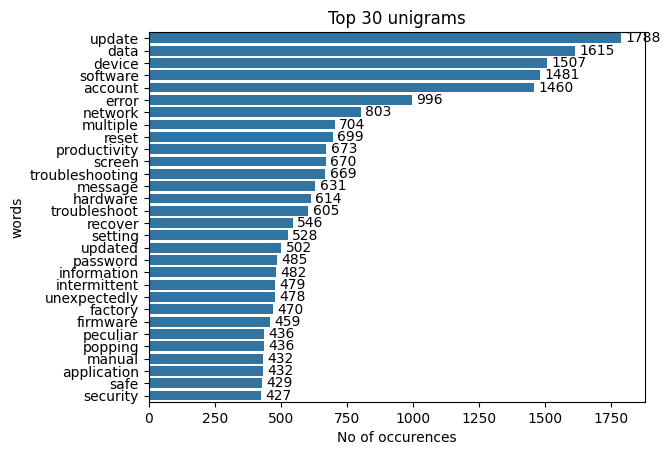

In [51]:
# Plot the top 30 unigrams

unigram_plot = sns.barplot(x=unigram_freq['Frequency'], y=unigram_freq.index)

unigram_plot.bar_label(unigram_plot.containers[0], fmt="%d", padding = 3)

plt.title("Top 30 unigrams")
plt.xlabel("No of occurences")
plt.ylabel("words")

##### Bigram

In [52]:
# Create a bigram count vectorizer with a maximum of 30 features and fit it to the preprocessed text for TF-IDF representation, then print the vocabulary of the vectorizer

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features = 30)
bigram_matrix = bigram_vectorizer.fit_transform(df['Tfidf_ticket_description'])
bigram_vectorizer.vocabulary_

{'troubleshooting manual': np.int64(27),
 'intermittent unexpectedly': np.int64(12),
 'original charger': np.int64(19),
 'charger charging': np.int64(2),
 'sudden decrease': np.int64(26),
 'decrease battery': np.int64(6),
 'battery life': np.int64(1),
 'life longer': np.int64(14),
 'access account': np.int64(0),
 'factory reset': np.int64(10),
 'updated firmware': np.int64(29),
 'firmware update': np.int64(11),
 'concerned security': np.int64(3),
 'security data': np.int64(24),
 'data safe': np.int64(5),
 'software update': np.int64(25),
 'experiencing multiple': np.int64(9),
 'multiple device': np.int64(18),
 'device model': np.int64(7),
 'model widespread': np.int64(17),
 'data loss': np.int64(4),
 'reported similar': np.int64(22),
 'peculiar error': np.int64(20),
 'error message': np.int64(8),
 'message popping': np.int64(16),
 'popping screen': np.int64(21),
 'running latest': np.int64(23),
 'latest version': np.int64(13),
 'update device': np.int64(28),
 'lost data': np.int64(15)}

In [53]:
# Create a DataFrame of the bigram frequencies by summing the bigram matrix and sorting the values in descending order

bigram_freq = pd.DataFrame(
    bigram_matrix.sum(axis = 0).T,
    index = bigram_vectorizer.get_feature_names_out(),
    columns = ["Frequency"]
).sort_values(by="Frequency", ascending = False)

Text(0, 0.5, 'words')

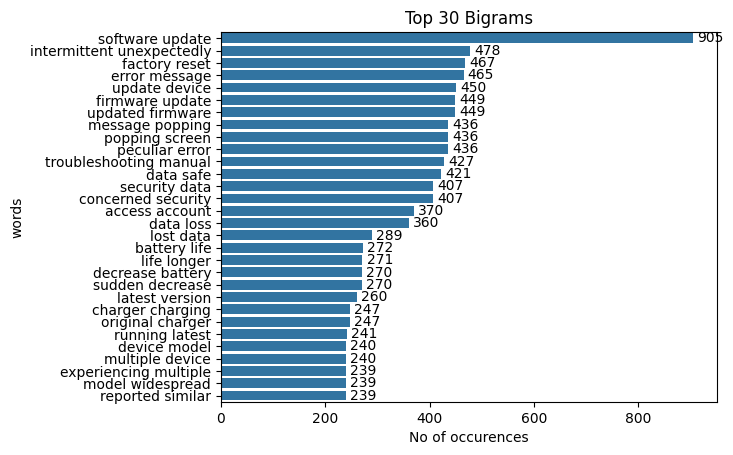

In [54]:
# Plot the top 30 bigrams

bigram_plot = sns.barplot(x=bigram_freq['Frequency'], y=bigram_freq.index)

bigram_plot.bar_label(bigram_plot.containers[0], fmt="%d", padding = 3)
plt.title("Top 30 Bigrams")
plt.xlabel("No of occurences")
plt.ylabel("words")

##### N-gram

In [55]:
# Create a n-gram count vectorizer with a maximum of 30 features and fit it to the preprocessed text for TF-IDF representation, then print the vocabulary of the vectorizer

ngram_vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features = 30)
ngram_matrix = ngram_vectorizer.fit_transform(df['Tfidf_ticket_description'])
ngram_vectorizer.vocabulary_

{'original charger charging': np.int64(16),
 'sudden decrease battery': np.int64(24),
 'decrease battery life': np.int64(5),
 'battery life longer': np.int64(0),
 'updated firmware update': np.int64(28),
 'troubleshooting official website': np.int64(25),
 'consistently feature application': np.int64(4),
 'concerned security data': np.int64(3),
 'security data safe': np.int64(20),
 'experiencing multiple device': np.int64(10),
 'multiple device model': np.int64(14),
 'device model widespread': np.int64(6),
 'device reported similar': np.int64(7),
 'device setting configured': np.int64(8),
 'setting configured correctly': np.int64(21),
 'peculiar error message': np.int64(17),
 'error message popping': np.int64(9),
 'message popping screen': np.int64(13),
 'worried hardware require': np.int64(29),
 'hardware require repair': np.int64(12),
 'require repair replacement': np.int64(18),
 'software update running': np.int64(23),
 'update running latest': np.int64(27),
 'running latest version'

In [56]:
# Create a DataFrame of the n-gram frequencies by summing the n-gram matrix and sorting the values in descending order

ngram_freq = pd.DataFrame(
    ngram_matrix.sum(axis = 0).T,
    index = ngram_vectorizer.get_feature_names_out(),
    columns = ["Frequency"]
).sort_values(by="Frequency", ascending = False)

Text(0, 0.5, 'words')

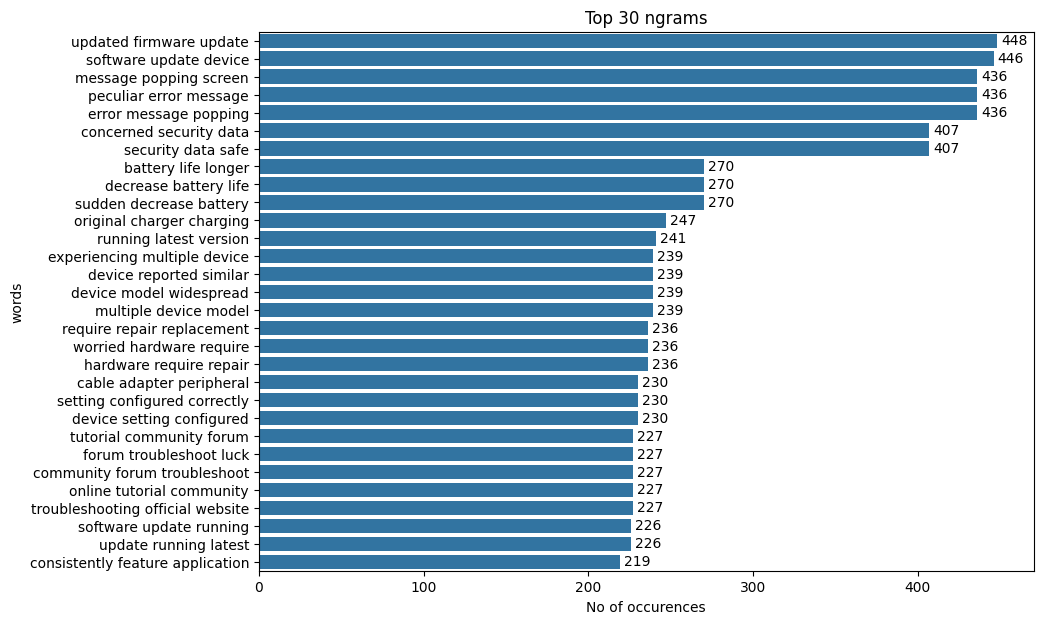

In [57]:
# Plot the top 30 n-grams

plt.figure(figsize=(10,7))

ngram_plot = sns.barplot(x=ngram_freq['Frequency'], y=ngram_freq.index)

ngram_plot.bar_label(ngram_plot.containers[0], fmt="%d", padding = 3)
plt.title("Top 30 ngrams")
plt.xlabel("No of occurences")
plt.ylabel("words")

In [58]:
# Save the preprocessed DataFrame to a new CSV file for later use in text representation and topic modeling

df.to_csv('../data/customer_support_tickets_preprocessed.csv', index = False)